In [ ]:
#jsut to check the columns
import pandas as pd
df = pd.read_csv(
    "D:/SEM 6/TSA/Project/data/processed/power_clean_hourly.csv")
print(df.columns)

Index(['DateTime', 'Global_active_power', 'Global_reactive_power', 'Voltage',
       'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')


In [6]:
import pandas as pd

df = pd.read_csv(
    "D:/SEM 6/TSA/Project/data/processed/power_clean_hourly.csv",
    parse_dates=["DateTime"]
)

df.set_index("DateTime", inplace=True)


# convert to daily average
df_daily = df.resample("D").mean()
df_daily.head()


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
DateTime,,,,,,,
2006-12-16,3.120298,0.096233,236.152341,13.369524,0.000000,1.330159,12.692063
2006-12-17,2.354486,0.156949,240.087028,9.999028,1.411806,2.907639,9.264583
2006-12-18,1.530435,0.112356,241.231694,6.421667,0.738194,1.820139,9.734722
2006-12-19,1.157079,0.104821,241.999313,4.926389,0.582639,5.279167,4.303472
2006-12-20,1.545658,0.111804,242.308063,6.467361,0.000000,1.838889,9.765972


In [7]:
df_daily.to_csv(
    "D:/SEM 6/TSA/Project/data/processed/power_clean_daily.csv",
    index_label="DateTime"
)


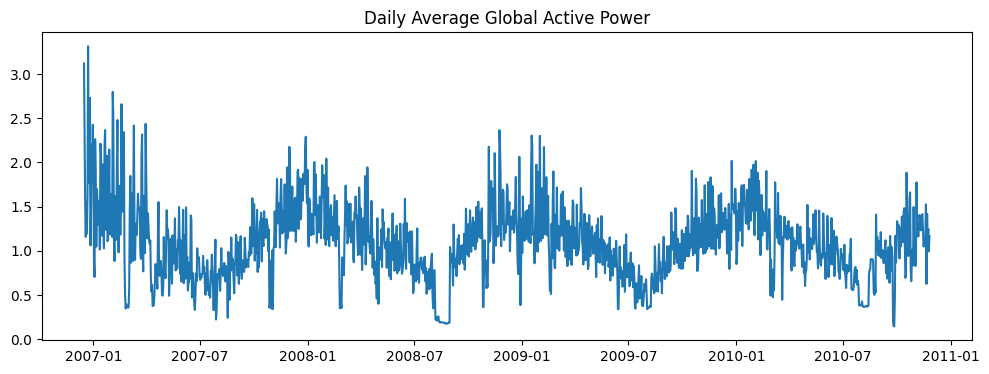

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(df_daily["Global_active_power"])
plt.title("Daily Average Global Active Power")
plt.show()


In [9]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(df_daily["Global_active_power"].dropna())

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])


ADF Statistic: -3.734364292254253
p-value: 0.003654948997613025


In [10]:
from statsmodels.tsa.stattools import kpss

kpss_stat, p_value, _, _ = kpss(
    df_daily["Global_active_power"].dropna(),
    regression="c"
)

print("KPSS Statistic:", kpss_stat)
print("p-value:", p_value)


KPSS Statistic: 0.22531087314044781
p-value: 0.1


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_5292\585588469.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, p_value, _, _ = kpss(


In [11]:
import numpy as np

df_daily["log_power"] = np.log1p(df_daily["Global_active_power"])


In [12]:
df_daily["log_diff"] = df_daily["log_power"].diff()
stationary_series = df_daily["log_diff"].dropna()


In [13]:
adf_result = adfuller(stationary_series)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])


ADF Statistic: -10.60906864046669
p-value: 5.898110290467789e-19


In [14]:
kpss_stat, p_value, _, _ = kpss(stationary_series, regression="c")

print("KPSS Statistic:", kpss_stat)
print("p-value:", p_value)


KPSS Statistic: 0.14372962265822187
p-value: 0.1


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_5292\2534998057.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, p_value, _, _ = kpss(stationary_series, regression="c")


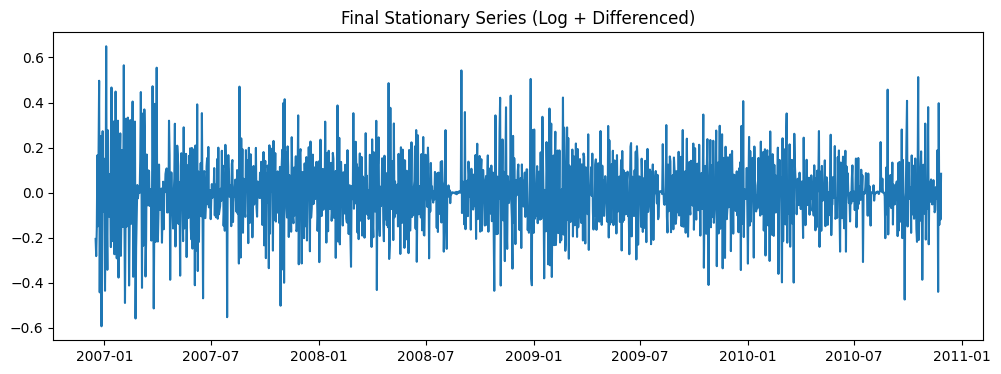

In [15]:
plt.figure(figsize=(12,4))
plt.plot(stationary_series)
plt.title("Final Stationary Series (Log + Differenced)")
plt.show()


In [18]:
stationary_series.to_csv(
    "D:/SEM 6/TSA/Project/data/processed/final_stationary_series.csv",
    header=True
)
